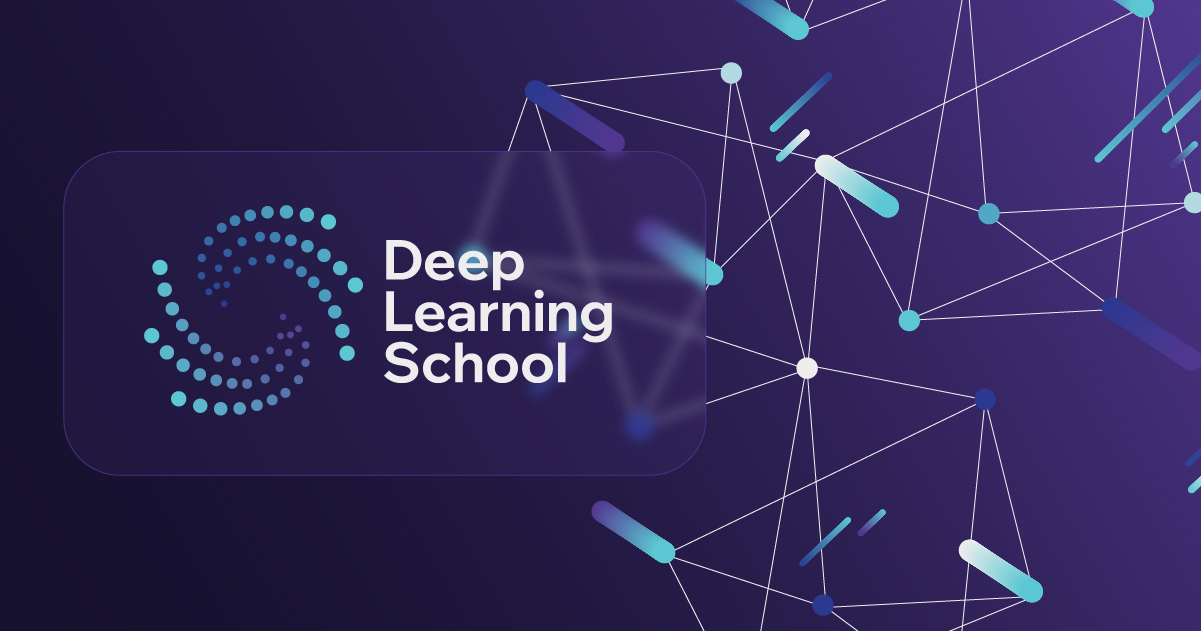

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Библиотека sklearn и классификация с помощью KNN</b></h1>

## Описание домашнего задания

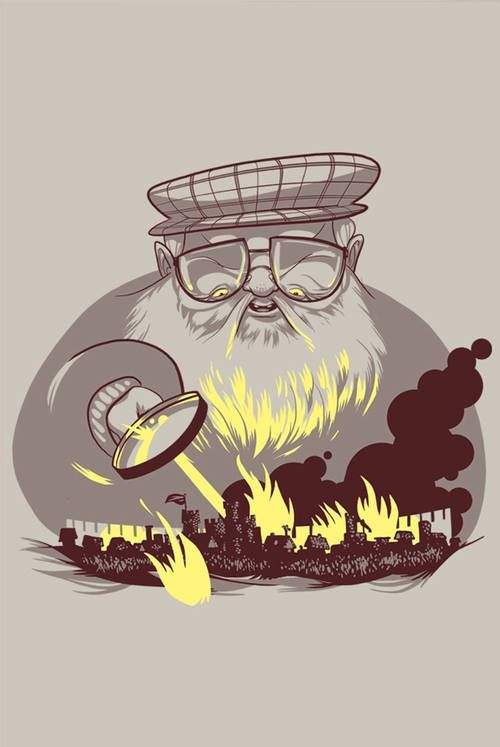

В данном задании вы будете работать с датасетом о персонажах из вселенной Игры Престолов [A Wiki of Ice and Fire](http://awoiaf.westeros.org/). Вам предстоит предсказать, кто из персонажей умрет, а кто останется вживых.



Описание данных:

* **name**: Имя персонажа

* **Title**: Социальный статус или знатность

* **House**: Дом, к которому принадлежит персонаж

* **Culture**: Социальная группа, к которой принадлежит персонаж

* **book1/2/3/4/5**: Появление персонажа в книге

* **Is noble**: Знатность персонажа, основанное на титуле

* **Age**: Отсчет времени: 305 AC

* **male**: Мужчина или женщина

* **dateOfBirth**: дата рождения

* **Spouse**: Имя супруги\а персонажа

* **Father**: Имя отца персонажа

* **Mother**: Имя матери персонажа

* **Heir**: Имя наследника персонажа

* **Is married**: Represents whether the character is married

* **Is spouse alive**: Represents whether character's spouse is alive

* **Is mother alive:** Жива ли мать персонажа

* **Is heir alive:** Жив ли наследник персонажа

* **Is father alive:** Указывает, жив ли отец персонажа

* **Number dead relations:** Количество умерших персонажей, с которыми персонаж связан

* **Popularity score:** Количество внутренних входящих и исходящих ссылок на страницу персонажей в вики http://awoiaf.westeros.org

Целевая переменная:
* **isAlive**: жив ли персонаж в книге

Оценивание:

Баллы считаются следующим образом:

1) $1.00 \geqslant score \geqslant 0.75$ --- 5 баллов

2) $0.75 > score \geqslant 0.65$ --- 4 балла

3) $0.65 > score \geqslant 0.55$ --- 3 балла

4) $0.55 > score \geqslant 0.50$ --- 2 балла

5) $0.50 > score \geqslant 0.45$ --- 1 балл

6) $0.45 > score$ --- 0 баллов

## Часть 1. Анализ и предобработка данных

Здесь вам необходимо сделать все шаги, которые обсуждались в первой части семинара.
* Предобработка данных
  * Обработка пропущенных данных
  * Создание новых признаков
  * Удаление ненужных столбцов
* Анализ данных
  * Анализ целевой переменной
  * Анализ признаков
  * Анализ влияния признаков на целевую переменную
* Подготовка данных для обучения модели

Загружаем датасет

In [100]:
!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset

Downloading...
From: https://drive.google.com/uc?id=1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
To: /content/game_of_thrones_test.csv
100% 37.3k/37.3k [00:00<00:00, 69.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v
To: /content/game_of_thrones_train.csv
100% 138k/138k [00:00<00:00, 98.5MB/s]


**Задание 1.1.** Импортируйте библиотеки pandas, matplotlib, seaborn

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Задание 1.2.** Загрузите датасет в Pandas DataFrame при помощи функции `read_csv`. Вместо дефолтных наименований строк `0,1,...`, при помощи параметра `index_col`, сделайте значения колонки `S.No` наименованиями строк:

In [102]:
df = pd.read_csv("/content/game_of_thrones_train.csv", index_col = "S.No")

In [103]:
df_test = pd.read_csv("/content/game_of_thrones_test.csv", index_col = "S.No")

**Задание 1.3.** Предобработка (очистка) данных.

Проанализируйте, если в колонках NaN значения. Если есть, примите решение, как вы их будете обрабатывать. Вы можете либо удалить их, либо заполнить каким нибудь значением (например, медианой или модой).

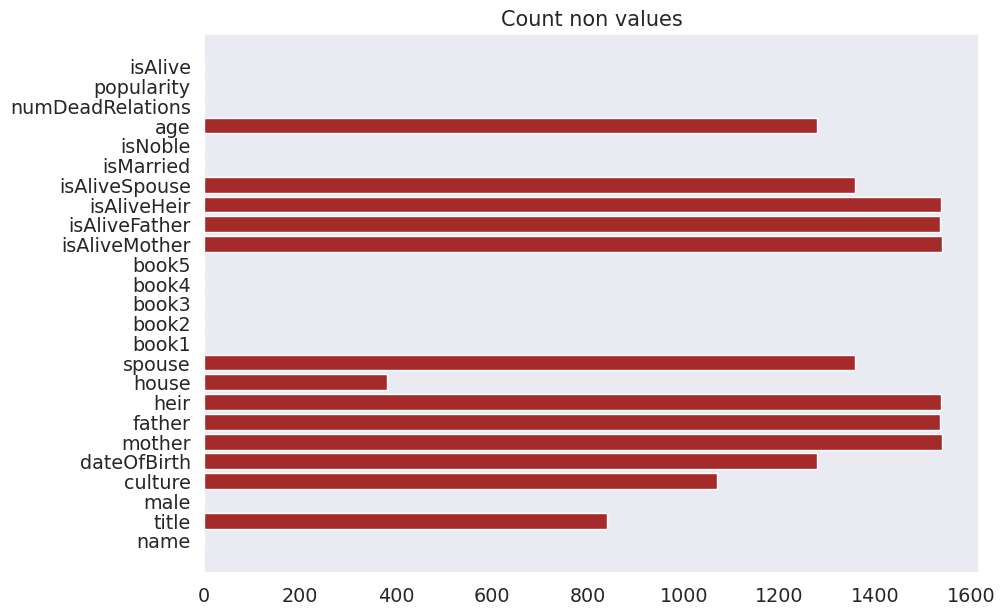

In [104]:
df.isna().sum(axis = 0)

data = df.isna().sum(axis = 0)
plt.figure(figsize=(10, 7))
plt.barh(data.index, data.values, facecolor='brown')
plt.title("Count non values")
plt.grid()

plt.show()

**Задание 1.4.** Создайте новые признаки.
* Создайте признак isPopular. У вас есть в таблице признак popularity score, поставьте какой то порог, например, 0.5, и пусть те персонажи, у которых popularity score меньше 0.5, непопулярны, т.е. isPopular = 0. Если же выше 0.5, тогда пусть isPopular=1.
* Создайте признак boolDeadRelations. Давайте упростим признак numDeadRelations, и просто поделим людей на тех, у кого были хоть какие то отношения с мертвыми персонажами, т.е. numDeadRelations > 0, и те, у которых не было, т.е. numDeadRelations = 0.
* Упростите признак culture, объединив схожие названия в один.


In [105]:
cult = {
    'Summer Islands': ['summer islands', 'summer islander', 'summer isles'],
    'Ghiscari': ['ghiscari', 'ghiscaricari',  'ghis'],
    'Asshai': ["asshai'i", 'asshai'],
    'Lysene': ['lysene', 'lyseni'],
    'Andal': ['andal', 'andals'],
    'Braavosi': ['braavosi', 'braavos'],
    'Dornish': ['dornishmen', 'dorne', 'dornish'],
    'Myrish': ['myr', 'myrish', 'myrmen'],
    'Westermen': ['westermen', 'westerman', 'westerlands'],
    'Westerosi': ['westeros', 'westerosi'],
    'Stormlander': ['stormlands', 'stormlander'],
    'Norvoshi': ['norvos', 'norvoshi'],
    'Northmen': ['the north', 'northmen'],
    'Free Folk': ['wildling', 'first men', 'free folk'],
    'Qartheen': ['qartheen', 'qarth'],
    'Reach': ['the reach', 'reach', 'reachmen'],
}

In [106]:
df['isPopular'] = df['popularity'].apply(lambda x: 1 if x >= 0.5 else 0)
df['boolDeadRelations'] = df['numDeadRelations'].apply(lambda x: 1 if x > 0 else 0)

In [107]:
df['culture'] = df['culture'].fillna('Unknown')

def simplify_culture(culture):
  culture = culture.lower()
  if culture in ['summer islands', 'summer islander', 'summer isles']:
    return 'Summer Islands'
  elif culture in ['ghiscari', 'ghiscaricari',  'ghis']:
    return 'Ghiscari'
  elif culture in ["asshai'i", 'asshai']:
    return 'Asshai'
  elif culture in ['lysene', 'lyseni']:
    return 'Lysene'
  elif culture in ['andal', 'andals']:
    return 'Andal'
  elif culture in ['braavosi', 'braavos']:
    return 'Braavosi'
  elif culture in ['dornishmen', 'dorne', 'dornish']:
    return 'Dornish'
  elif culture in ['myr', 'myrish', 'myrmen']:
    return 'Myrish'
  elif culture in ['westermen', 'westerman', 'westerlands']:
    return 'Westermen'
  elif culture in ['westeros', 'westerosi']:
    return 'Westerosi'
  elif culture in ['stormlands', 'stormlander']:
    return 'Stormlander'
  elif culture in ['norvos', 'norvoshi']:
    return 'Norvoshi'
  elif culture in ['the north', 'northmen']:
    return 'Northmen'
  elif culture in ['wildling', 'first men', 'free folk']:
    return 'Free Folk'
  elif culture in ['qartheen', 'qarth']:
    return 'Qartheen'
  elif culture in ['the reach', 'reach', 'reachmen']:
    return 'Reach'
  else:
    return culture


df['culture'] = df['culture'].apply(simplify_culture)

In [108]:
df['house'] = df['house'].fillna('Unknown')
df['title'] = df['title'].fillna('Unknown')
df['mother'] = df['mother'].fillna('Unknown')
df['father'] = df['father'].fillna('Unknown')
df['heir'] = df['heir'].fillna('Unknown')
df['spouse'] = df['spouse'].fillna('Unknown')
df['isAliveHeir'] = df['isAliveHeir'].fillna(0)
df['isAliveSpouse'] = df['isAliveSpouse'].fillna(0)

df.sample(n = 3)

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive,isPopular,boolDeadRelations
S.No,,,,,,,,,,,,,,,,,,,,,
777,Mero,Unknown,1,Braavosi,NaN,Unknown,Unknown,Unknown,Second Sons,Unknown,...,0.0,0.0,0,0,NaN,0,0.046823,0,0,0
137,Rymolf,Unknown,0,ironborn,NaN,Unknown,Unknown,Unknown,House Greyjoy,Unknown,...,0.0,0.0,0,0,NaN,0,0.000000,1,0,0
566,Gyloro Dothare,Unknown,1,Braavosi,NaN,Unknown,Unknown,Unknown,Unknown,Unknown,...,0.0,0.0,0,0,NaN,0,0.013378,1,0,0


In [109]:
df['age'] = df.groupby('house')['age'].transform(lambda x: x.fillna(x.median()))
df['age'] = df['age'].fillna(df['age'].median())

df.head(n=3)

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive,isPopular,boolDeadRelations
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,Unknown,1,unknown,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,Unknown,Unknown,...,0.0,0.0,0,0,26.0,11,0.605351,0,1,1
2,Walder Frey,Lord of the Crossing,1,rivermen,208.0,Unknown,Unknown,Unknown,House Frey,Perra Royce,...,0.0,1.0,1,1,97.0,1,0.896321,1,1,1
3,Addison Hill,Ser,1,unknown,NaN,Unknown,Unknown,Unknown,House Swyft,Unknown,...,0.0,0.0,0,1,26.0,0,0.267559,1,0,0


**Задание 1.5.** Проанализируйте, какие столбцы являются существенными и влияют на предсказание, а какие нет. Удалите ненужные столбцы по вашему мнению.

In [110]:
categorical_cols = [
    'name', 'title', 'male', 'culture', 'mother', 'father', 'heir', 'house', 'spouse',
    'book1', 'book2', 'book3', 'book4', 'book5', 'isAliveMother', 'isAliveFather',
    'isAliveHeir', 'isAliveSpouse', 'isMarried', 'isNoble', 'isPopular', 'boolDeadRelations'
]
numeric_cols = ['dateOfBirth', 'age', 'numDeadRelations', 'popularity']

In [111]:
#Lookup for unique values (categorial)
print("\nУникальные значения в каждом столбце:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} уникальных значений")


Уникальные значения в каждом столбце:
name: 1557 уникальных значений
title: 196 уникальных значений
male: 2 уникальных значений
culture: 34 уникальных значений
dateOfBirth: 105 уникальных значений
mother: 17 уникальных значений
father: 20 уникальных значений
heir: 21 уникальных значений
house: 316 уникальных значений
spouse: 187 уникальных значений
book1: 2 уникальных значений
book2: 2 уникальных значений
book3: 2 уникальных значений
book4: 2 уникальных значений
book5: 2 уникальных значений
isAliveMother: 2 уникальных значений
isAliveFather: 2 уникальных значений
isAliveHeir: 2 уникальных значений
isAliveSpouse: 2 уникальных значений
isMarried: 2 уникальных значений
isNoble: 2 уникальных значений
age: 78 уникальных значений
numDeadRelations: 14 уникальных значений
popularity: 117 уникальных значений
isAlive: 2 уникальных значений
isPopular: 2 уникальных значений
boolDeadRelations: 2 уникальных значений


In [112]:
from typing import List

rows = df.shape[0]
columns = df.columns

list_drop = set()

#Lookup the none values > 70%
def empty_rows(list_columns: list):
  global list_drop
  for column in list_columns:
    if df[column].isna().sum() > round(rows * 0.7, 0):
      list_drop.add(column)
    else:
      continue
  return list_drop

#Lookup for unique values
def unique_values(list_columns: list):
  global list_drop
  for column in list_columns:
    if df[column].nunique() == 1:
      list_drop.add(column)
    elif df[column].nunique() == rows:
      list_drop.add(column)
    else:
      continue
  return list_drop

empty_rows(columns)
unique_values(columns)

list_drop.update(['numDeadRelations', 'dateOfBirth', 'spouse', 'popularity'])


print(list_drop)

{'name', 'dateOfBirth', 'spouse', 'isAliveMother', 'numDeadRelations', 'isAliveFather', 'popularity'}


In [113]:
data = df
data.drop(columns = list_drop, inplace = True, errors='ignore')
data

,title,male,culture,mother,father,heir,house,book1,book2,book3,book4,book5,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,isAlive,isPopular,boolDeadRelations
S.No,,,,,,,,,,,,,,,,,,,,
1,Unknown,1,unknown,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,Unknown,0,0,0,0,0,0.0,0.0,0,0,26.0,0,1,1
2,Lord of the Crossing,1,rivermen,Unknown,Unknown,Unknown,House Frey,1,1,1,1,1,0.0,1.0,1,1,97.0,1,1,1
3,Ser,1,unknown,Unknown,Unknown,Unknown,House Swyft,0,0,0,1,0,0.0,0.0,0,1,26.0,1,0,0
4,Queen,0,unknown,Unknown,Unknown,Unknown,House Arryn,0,0,0,0,0,0.0,0.0,1,1,23.0,0,0,0
5,Greenstone,0,Dornish,Unknown,Unknown,Unknown,House Santagar,0,0,0,1,0,0.0,1.0,1,1,29.0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,Archmaester,1,unknown,Unknown,Unknown,Unknown,Unknown,1,0,1,1,0,0.0,0.0,0,1,26.0,1,0,0
1554,Unknown,0,unknown,Unknown,Unknown,Unknown,Unknown,1,1,0,0,0,0.0,0.0,0,0,26.0,0,0,0
1555,Unknown,1,unknown,Unknown,Unknown,Unknown,House Seaworth,0,1,1,1,1,0.0,0.0,0,0,14.0,0,0,0


**Задание 1.6.** Проанализируйте целевую переменную. Посмотрите, является ли она категориальной или количественной. Так как мы говорим о задаче классификации, проанализируйте является ли датасет сбалансированным по классам или нет.

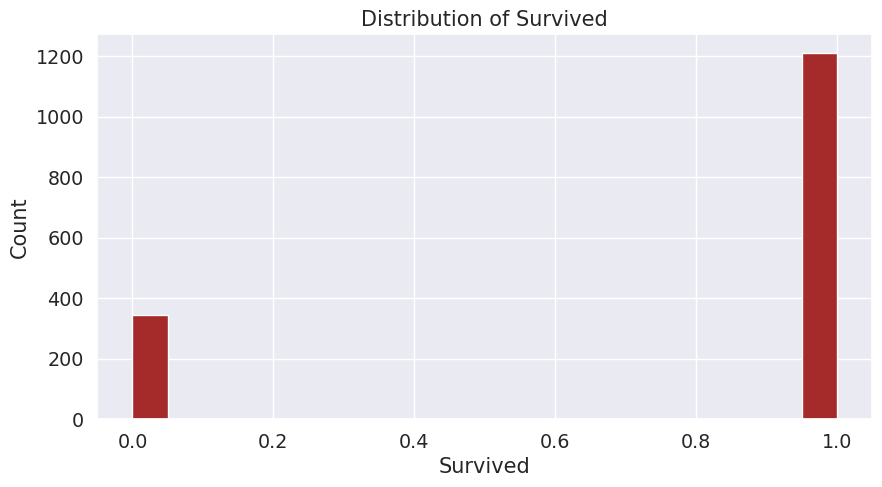

In [114]:
plt.figure(figsize=(10, 5))
df['isAlive'].hist(density=False, bins = 20, facecolor = 'brown')

plt.ylabel('Count')
plt.xlabel('Survived')

plt.title('Distribution of Survived')
plt.grid

plt.show()

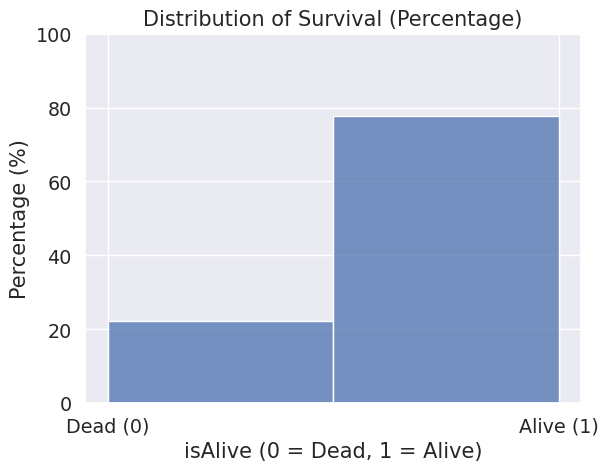

In [115]:
weights = [100 / len(data)] * len(data)

sns.histplot(data=data, x='isAlive', weights=weights, bins=2)
plt.title('Distribution of Survival (Percentage)')
plt.xlabel('isAlive (0 = Dead, 1 = Alive)')
plt.ylabel('Percentage (%)')
plt.xticks(ticks=[0, 1], labels=['Dead (0)', 'Alive (1)'])
plt.ylim(0, 100)
plt.show()

In [116]:
df.shape

(1557, 20)

from sklearn.preprocessing import LabelEncoder**Задание 1.7.** Проанализируйте признаки.
  * Обработайте категориальные признаки и переведите их в числа. Можете выбрать любой кодировщик.
  * Проанализируйте количественные признаки. Есть ли корреляция между признаками?

In [117]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    'title', 'male', 'culture', 'mother', 'father', 'heir', 'house',
    'book1', 'book2', 'book3', 'book4', 'book5', 'isAliveHeir', 'isAliveSpouse',
    'isMarried', 'isNoble', 'isPopular', 'boolDeadRelations'
]

label_encoding = LabelEncoder()

for column in categorical_cols:
  data[column] = label_encoding.fit_transform(data[column])

data.sample(n=3)

,title,male,culture,mother,father,heir,house,book1,book2,book3,book4,book5,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,isAlive,isPopular,boolDeadRelations
S.No,,,,,,,,,,,,,,,,,,,,
1187,163,1,29,14,18,20,223,0,0,1,0,0,0,0,0,1,26.0,1,0,0
1141,183,0,7,14,18,20,181,0,0,0,1,1,0,0,0,0,27.0,1,0,0
1207,135,1,29,14,18,20,222,0,1,1,1,1,0,0,0,1,14.0,0,0,0


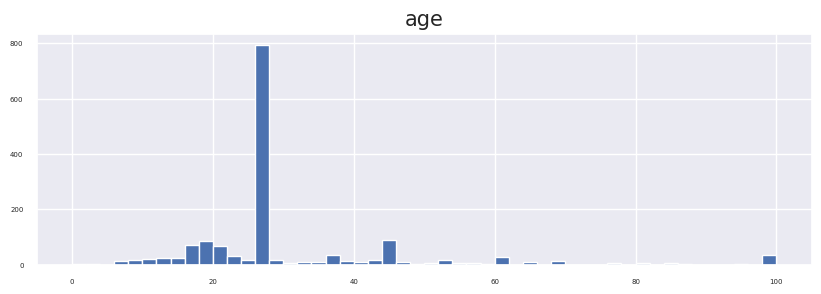

In [118]:
numeric_cols = ['age']
data[numeric_cols].hist(figsize=(10, 3), bins=50,xlabelsize=5, ylabelsize=5, grid=False)
plt.grid()
plt.show()


**Задание 1.8.** Проанализируйте влияние признаков на целевую переменную.

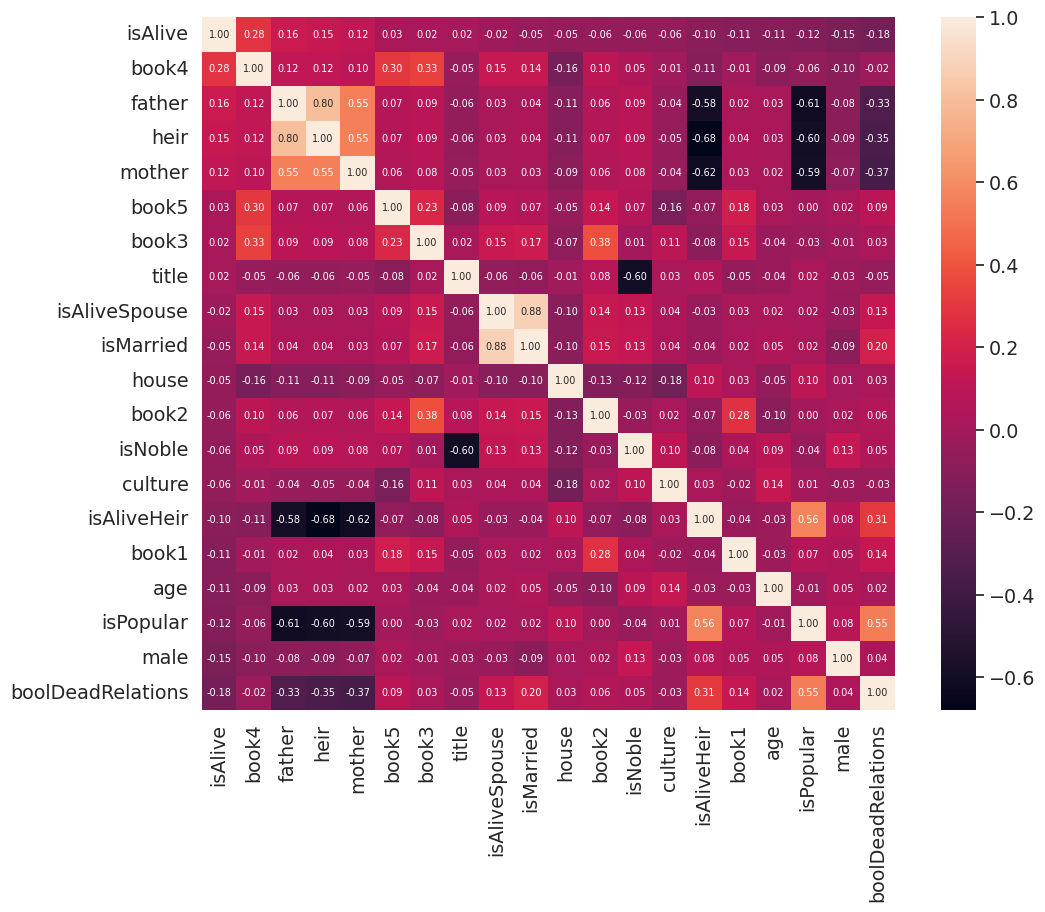

In [119]:
# correlation matrix
import numpy as np
corrmat = data.corr()
f, ax = plt.subplots(figsize=(12, 9))

k = data.shape[1] # number of variables for heatmap
cols = corrmat.nlargest(k, 'isAlive')['isAlive'].index
cm = np.corrcoef(data[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 7}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()

In [120]:
cols_to_drop = ['book1', 'book2', 'book3', 'book4', 'book5', 'title', 'house', 'culture']
data.drop(columns=cols_to_drop, inplace = True, errors='ignore')
data.drop(columns=['isAliveSpouse'], errors='ignore')
data.drop(columns=['isNoble'], errors='ignore')
data.head(n=3)

,male,mother,father,heir,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,isAlive,isPopular,boolDeadRelations
S.No,,,,,,,,,,,,
1,1,11,8,0,0,0,0,0,26.0,0,1,1
2,1,14,18,20,0,1,1,1,97.0,1,1,1
3,1,14,18,20,0,0,0,1,26.0,1,0,0


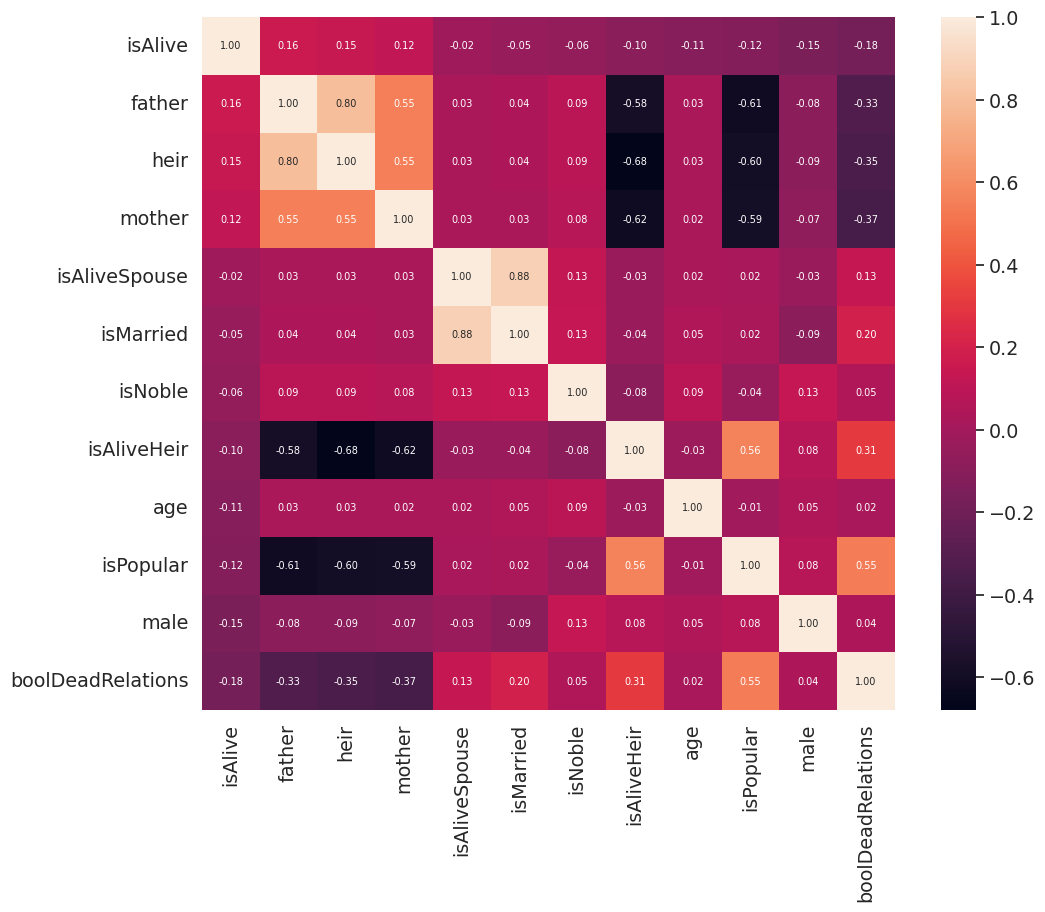

In [121]:
# correlation matrix
import numpy as np
corrmat = data.corr()
f, ax = plt.subplots(figsize=(12, 9))

k = data.shape[1] # number of variables for heatmap
cols = corrmat.nlargest(k, 'isAlive')['isAlive'].index
cm = np.corrcoef(data[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 7}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()

**Задание 1.9.** Создайте переменные `X`, которая будет хранить только значения признаков, и `y`, которая будет хранить только значения целевой переменной.

In [122]:
X = data.drop('isAlive', axis=1)
y = data['isAlive']

**Задание 1.10.** Разделите датасет на train и test часть при помощи функции `train_test_split`

In [123]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Часть 2. Обучение моделей

В данной части домашнего задания, мы хотим научиться обучать модели для задачи классификации на наших данных.

**Задание 2.1.** Импортируйте следующие модели из библиотеки `sklearn`
* LogisticRegression
* RandomForestClassifier
* AdaBoostClassifier
* GaussianProcessClassifier
* GaussianNB
* KNeighborsClassifier
* SVC
* DecisionTreeClassifier


В качестве примера, импортируем модель `LogisticRegression`

Импортируйте остальные модели из библиотеки `sklearn`. Чтобы понять как это сделать, воспользуйтесь официальный документацией `sklearn` $→$ [тык](https://scikit-learn.org/dev/user_guide.html). По ключевому названию модели, вы сможете найти необходимую информацию о том, как можно импортировать модель из библиотеки.

In [124]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from imblearn.over_sampling import SMOTE

**Задание 2.2.** Обучите модель и сделайте предсказание на тестовой выборке

В качестве примера, обучим модель `LogisticRegression` и сделаем на ней предсказания на тестовой выборке.

In [125]:
#mashtabing data
#from sklearn.preprocessing import StandardScaler

#scaler = StandardScaler()
#scaler.fit(X_train)
#X_train = scaler.transform(X_train)
#X_test = scaler.transform(X_test)

Аналогичным образом обучите остальные модели и сделайте предсказания на тестовой выборке.

In [126]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gaussian Process": GaussianProcessClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

for name, model in models.items():
    try:
        print(f"\nОбучение модели: {name}")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        print(f"Метрики для {name}:")
        print(classification_report(y_test, y_pred))
    except Exception as e:
        print(f"Ошибка в модели {name}: {e}")




Обучение модели: Logistic Regression
Метрики для Logistic Regression:
              precision    recall  f1-score   support

           0       0.64      0.09      0.16        77
           1       0.77      0.98      0.86       235

    accuracy                           0.76       312
   macro avg       0.70      0.54      0.51       312
weighted avg       0.74      0.76      0.69       312


Обучение модели: Random Forest


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Метрики для Random Forest:
              precision    recall  f1-score   support

           0       0.42      0.14      0.21        77
           1       0.77      0.94      0.84       235

    accuracy                           0.74       312
   macro avg       0.60      0.54      0.53       312
weighted avg       0.68      0.74      0.69       312


Обучение модели: AdaBoost
Метрики для AdaBoost:
              precision    recall  f1-score   support

           0       0.54      0.09      0.16        77
           1       0.77      0.97      0.86       235

    accuracy                           0.76       312
   macro avg       0.65      0.53      0.51       312
weighted avg       0.71      0.76      0.68       312


Обучение модели: Gaussian Process
Метрики для Gaussian Process:
              precision    recall  f1-score   support

           0       0.64      0.12      0.20        77
           1       0.77      0.98      0.86       235

    accuracy                           0.

## Часть 3. Оцените качество моделей

Вам необходимо познакомиться с метриками задачи классификации из sklearn. Оцените все модели и выберите лучшую по метрике качества Accuracy.

С метриками классификации вы можете ознакомиться в [Yandex ML Book](https://education.yandex.ru/handbook/ml/article/metriki-klassifikacii-i-regressii).

Для простоты в данном домашнем задании мы будем работать с самой базовой метрикой для задачи классификации - accuracy.

**Задание 3.1.** Вам необходимо посчитать метрику для всех моделей и выбрать лучшую модель.

Сначала импортируем необходимую функцию из библиотеки sklearn для подсчета accuracy.

In [127]:
from sklearn.metrics import accuracy_score

В качестве примера, посчитаем метрику accuracy для модели `LogisticRegression`

In [128]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gaussian Process": GaussianProcessClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

for name, model in models.items():
    try:
        print(f"\nОбучение модели: {name}")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        print(f"Оценка предсказания для {name}: {accuracy}")
    except Exception as e:
        print(f"Ошибка в модели {name}: {e}")


Обучение модели: Logistic Regression
Оценка предсказания для Logistic Regression: 0.7628205128205128

Обучение модели: Random Forest


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Оценка предсказания для Random Forest: 0.7403846153846154

Обучение модели: AdaBoost
Оценка предсказания для AdaBoost: 0.7564102564102564

Обучение модели: Gaussian Process
Оценка предсказания для Gaussian Process: 0.7660256410256411

Обучение модели: Naive Bayes
Оценка предсказания для Naive Bayes: 0.7628205128205128

Обучение модели: KNN
Оценка предсказания для KNN: 0.7564102564102564

Обучение модели: SVM
Оценка предсказания для SVM: 0.7660256410256411

Обучение модели: Decision Tree
Оценка предсказания для Decision Tree: 0.7532051282051282


In [135]:
from sklearn.model_selection import GridSearchCV

param_grid_svm = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'class_weight': ['balanced', None]
}
grid_search_svm = GridSearchCV(SVC(random_state=42), param_grid_svm, cv=5, scoring='f1_macro', n_jobs=-1)

grid_search_svm.fit(X_train, y_train)
print("\nЛучшие параметры для SVM:", grid_search_svm.best_params_)
y_pred_svm = grid_search_svm.predict(X_test)
print("Метрики для SVM с оптимизацией:")
print(accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


param_grid_lr = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs', 'l1_ratio'],
    'max_iter': [100, 200]
}
grid_search_lr = GridSearchCV(LogisticRegression(random_state=42), param_grid_lr, cv=5, scoring='f1', n_jobs=-1)
grid_search_lr.fit(X_train, y_train)
print("\nЛучшие параметры для Logistic Regression:", grid_search_lr.best_params_)
y_pred_lr = grid_search_lr.predict(X_test)
print("Метрики для Logistic Regression с оптимизацией:")
print(accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', None]
}
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='f1_macro', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)
print("\nЛучшие параметры для Random Forest:", grid_search_rf.best_params_)
y_pred_rf = grid_search_rf.predict(X_test)
print("Метрики для Random Forest с оптимизацией:")
print(accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Лучшие параметры для SVM: {'C': 1, 'class_weight': 'balanced', 'gamma': 0.01, 'kernel': 'rbf'}
Метрики для SVM с оптимизацией:
0.7019230769230769
              precision    recall  f1-score   support

           0       0.41      0.45      0.43        77
           1       0.81      0.78      0.80       235

    accuracy                           0.70       312
   macro avg       0.61      0.62      0.61       312
weighted avg       0.71      0.70      0.71       312



/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
30 fits failed out of a total of 90.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
26 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/_


Лучшие параметры для Logistic Regression: {'C': 10, 'max_iter': 100, 'solver': 'lbfgs'}
Метрики для Logistic Regression с оптимизацией:
0.7628205128205128
              precision    recall  f1-score   support

           0       0.64      0.09      0.16        77
           1       0.77      0.98      0.86       235

    accuracy                           0.76       312
   macro avg       0.70      0.54      0.51       312
weighted avg       0.74      0.76      0.69       312


Лучшие параметры для Random Forest: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Метрики для Random Forest с оптимизацией:
0.6153846153846154
              precision    recall  f1-score   support

           0       0.30      0.43      0.35        77
           1       0.78      0.68      0.73       235

    accuracy                           0.62       312
   macro avg       0.54      0.55      0.54       312
weighted avg       0.66      0.62      0.63       312



Выберите лучшую модель.

### Файл `submission.csv`

Вам нужно вместо значений в `submission.csv` файле в колонке `isAlive`, подставить свои предсказания и сохранить измененный файл.

In [130]:
!gdown 1M14conWjAW2QLoyCXbHEAy8bql2f99eF

Downloading...
From: https://drive.google.com/uc?id=1M14conWjAW2QLoyCXbHEAy8bql2f99eF
To: /content/submission.csv
100% 2.74k/2.74k [00:00<00:00, 11.1MB/s]


In [131]:
submission = pd.read_csv("/content/submission.csv", index_col='S.No')

In [132]:
submission

,isAlive
S.No,
1558,0
1559,0
1560,0
1561,0
1562,0
...,...
1942,0
1943,0
1944,0


Как сохранить измененный Pandas DataFrame в csv файл:

In [133]:
submission.to_csv("/content/new_submission.csv", index=False)